# Churn Prediction Using Support Vector Classifier
In this notebook, I use the results from the [churn_eda](https://github.com/MonikaMitrovic/Churn_Prediction/blob/main/churn_eda.ipynb) analysis. Some columns are removed, and data transformations are applied based on what I learned before. Then, I train a Support Vector Classifier (SVC) and tune its hyperparameters to get the best results.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (confusion_matrix, precision_score, recall_score, 
                             f1_score, fbeta_score, average_precision_score, 
                                                          precision_recall_curve, auc, classification_report)
from sklearn.exceptions import UndefinedMetricWarning
import warnings

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)


1. **Data Import and Inspection**
    - The dataset is loaded from a CSV file, and column names are converted to lowercase for consistency.
    - A summary of the dataset is generated using `describe()`, and missing values are checked with `isna().sum()`.

In [3]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
df.columns = df.columns.str.lower()
df

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [5]:
df.describe().round()

,seniorcitizen,tenure,monthlycharges
count,7043.0,7043.0,7043.0
mean,0.0,32.0,65.0
std,0.0,25.0,30.0
min,0.0,0.0,18.0
25%,0.0,9.0,36.0
50%,0.0,29.0,70.0
75%,0.0,55.0,90.0
max,1.0,72.0,119.0


In [6]:
df.isna().sum()

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

In [7]:
df.nunique()

customerid          7043
gender                 2
seniorcitizen          2
partner                2
dependents             2
tenure                73
phoneservice           2
multiplelines          3
internetservice        3
onlinesecurity         3
onlinebackup           3
deviceprotection       3
techsupport            3
streamingtv            3
streamingmovies        3
contract               3
paperlessbilling       2
paymentmethod          4
monthlycharges      1585
totalcharges        6531
churn                  2
dtype: int64

2. **Removing Unnecessary Columns**
    - The columns `customerid`, `gender`, and `phoneservice` are removed as they do not contribute to the prediction of churn.
    - The `totalcharges` column is removed because it depends on `monthlycharges` and `tenure`. Keeping it would add redundant information to the model.

In [8]:
del df['customerid']
del df['phoneservice']
del df['gender']
del df['totalcharges']

3. **Creating New Features Based on Existing Columns**
    - A new binary feature `fiber_optic` is created by checking if the `internetservice` is 'Fiber optic'. If it is, the value is set to 'Yes', otherwise 'No'.
    - The `paymentmethod` column is used to create another binary feature `electronic_check`, which is `Yes` if the payment method is 'Electronic check' and `No` otherwise.

In [9]:
df['fiber_optic'] = (df['internetservice'] == 'Fiber optic').map({True: 'Yes', False: 'No'})

In [10]:
del df['internetservice']

In [11]:
df['electronic_check'] = (df['paymentmethod'] == 'Electronic check').map({True: 'Yes', False: 'No'})

In [12]:
del df['paymentmethod']

4. **Creating a New Feature for Additional Services**
    - A new column `additional_services` is created by summing up the number of 'Yes' responses for a list of services (`streamingmovies`, `streamingtv`, etc.). This feature indicates the total number of additional services a customer has subscribed to.
    - The individual service columns (e.g., `streamingmovies`, `streamingtv`, etc.) are dropped after creating the `additional_services` column, as they are no longer needed.

In [13]:
services = [
    'streamingmovies',
    'streamingtv',
    'techsupport',
    'deviceprotection',
    'onlinebackup',
    'onlinesecurity'
]

df['additional_services'] = (
    df[services]
    .apply(lambda col: col == 'Yes')
    .sum(axis=1)
)

In [14]:
del df['streamingmovies']
del df['streamingtv']
del df['techsupport']
del df['deviceprotection']
del df['onlinebackup']
del df['onlinesecurity']

In [15]:
df.columns

Index(['seniorcitizen', 'partner', 'dependents', 'tenure', 'multiplelines',
       'contract', 'paperlessbilling', 'monthlycharges', 'churn',
       'fiber_optic', 'electronic_check', 'additional_services'],
      dtype='object')

In [16]:
df.dtypes

seniorcitizen            int64
partner                 object
dependents              object
tenure                   int64
multiplelines           object
contract                object
paperlessbilling        object
monthlycharges         float64
churn                   object
fiber_optic             object
electronic_check        object
additional_services      int64
dtype: object

5. **Target Variable**
    - The `churn` column is used as the target variable and is encoded as 0 (No) and 1 (Yes). All remaining columns are used as input features X.

In [17]:
df['churn'].value_counts()

churn
No     5174
Yes    1869
Name: count, dtype: int64

In [18]:
y = df['churn']
X = df.drop(columns=['churn'])

In [19]:
y = y.map({
    "No": 0,
    "Yes": 1
})

### Data Splitting and Preprocessing Pipeline

The dataset is split into training, validation, and test sets using stratified sampling to preserve the class distribution of the target variable. The training set is used for model training, the validation set for model tuning, and the test set for final evaluation.

Categorical and numerical features are handled separately. Numerical features are converted to numeric values, missing values are imputed using the median, and features are scaled using standardization. The `contract` feature is encoded using ordinal encoding to preserve its natural order.

Categorical variables are encoded using one-hot encoding, while unknown categories are ignored. All preprocessing steps are combined into a single pipeline to ensure consistent data transformation during model training and evaluation.

In [20]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=11
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=11
)

In [21]:
cat_cols = ['partner', 'dependents',
        'multiplelines', 'fiber_optic', 'electronic_check', 'paperlessbilling']
num_cols = [c for c in X.columns if c not in cat_cols and c != 'contract']
contract_col = ['contract']

In [22]:
num_cols

['seniorcitizen', 'tenure', 'monthlycharges', 'additional_services']

In [23]:
cat_cols

['partner',
 'dependents',
 'multiplelines',
 'fiber_optic',
 'electronic_check',
 'paperlessbilling']

In [24]:
contract_order = [['Month-to-month', 'One year', 'Two year']]

In [25]:
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [26]:
for col in num_cols:
    df[col] = df[col].replace(r'^\s*$', np.nan, regex=True)

In [27]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ("scaler", StandardScaler())
                    ]), num_cols),
    ("contract", OrdinalEncoder(categories=contract_order), contract_col),
    ("cat", OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
                                ])

### SVC Model Training and Hyperparameter Tuning

An SVC model is trained using a preprocessing pipeline to ensure consistent data transformation. Class imbalance is handled using balanced class weights, and probability estimates are enabled for model evaluation.

Hyperparameter tuning is performed in two steps. First, GridSearchCV is used to explore a fixed set of values for the main SVC hyperparameters (`C`, `gamma`, and `kernel`). The model is evaluated using average precision with 10-fold cross-validation.

After that, RandomizedSearchCV is applied to further optimize the model by sampling hyperparameters from continuous distributions. This approach allows a wider search space and helps identify better-performing parameter combinations. The best model from the randomized search is selected for further evaluation.


Parameter tuning- GridSearchCV

In [28]:
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("svc", SVC(
        class_weight='balanced',
        probability=True,
        random_state=11
    ))
])

param_grid = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": ["scale", 0.001, 0.01, 0.1],
    "svc__kernel": ["rbf"]
}

grid_search = GridSearchCV(
    pipe,
    param_grid,
    scoring="average_precision",
    cv=10,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Grid best params:", grid_search.best_params_)
print("Grid best AP:", grid_search.best_score_)

Fitting 10 folds for each of 16 candidates, totalling 160 fits
Grid best params: {'svc__C': 100, 'svc__gamma': 0.001, 'svc__kernel': 'rbf'}
Grid best AP: 0.6618132818985293


Fine parameter tuning- RandomizedSearchCV

In [29]:
param_dist = {
    "svc__C": loguniform(10, 100),  
    "svc__gamma": loguniform(1e-3, 1e-1),  
    "svc__kernel": ["rbf"]
}

random_search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=40,                 
    scoring="average_precision",
    cv=10,
    random_state=11,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
print("Random best params:", random_search.best_params_)
print("Random best AP:", random_search.best_score_)

Fitting 10 folds for each of 40 candidates, totalling 400 fits
Random best params: {'svc__C': np.float64(11.759330461379749), 'svc__gamma': np.float64(0.0038065131484463556), 'svc__kernel': 'rbf'}
Random best AP: 0.6630113471628026


In [30]:
c_value = round(random_search.best_params_['svc__C'], 2)
gamma_value = round(random_search.best_params_['svc__gamma'], 3)

In [31]:
results = pd.DataFrame(random_search.cv_results_)

results[
    ['param_svc__C', 'param_svc__gamma',
     'mean_test_score', 'std_test_score']
].sort_values(by='mean_test_score', ascending=False).head()


,param_svc__C,param_svc__gamma,mean_test_score,std_test_score
22,11.759330,0.003807,0.663011,0.048486
21,11.749592,0.004352,0.662806,0.048045
5,53.698786,0.001650,0.662677,0.049766
20,11.579410,0.005361,0.661821,0.046550
27,54.053689,0.001336,0.661482,0.049423


The top-performing parameter combinations show similar values for `C` and `gamma`. Most of the best results are obtained with `C` values around 11–12 and `gamma` values between 0.003 and 0.005.
This indicates a stable region of good-performing hyperparameters rather than a single optimal value. The standard deviation of the scores is similar across combinations, suggesting consistent performance across cross-validation folds.


### Probability Calibration

The best SVC model is calibrated using Platt scaling (sigmoid method) to improve the quality of predicted probabilities. Calibration is performed on the validation set using cross-validation.

In [32]:
calibrated_model = CalibratedClassifierCV(
    estimator=best_model,
    method='sigmoid',
    cv=5
)
calibrated_model.fit(X_val, y_val)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...m_state=11))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the colum

### Validation Performance

The calibrated and uncalibrated models are evaluated on the validation set. Performance is assessed using confusion matrices, classification reports, and average precision.

- Calibrated

In [33]:
y_prob_val = calibrated_model.predict_proba(X_val)[:,1]
y_pred_val = (y_prob_val >= 0.5).astype(int) 
 
print("Confusion Matrix (Validation):")
print(confusion_matrix(y_val, y_pred_val))

print("\nClassification Report (Validation):")
print(classification_report(y_val, y_pred_val))

print("\nAverage Precision (Validation):", average_precision_score(y_val, y_prob_val))


Confusion Matrix (Validation):
[[690  86]
 [125 155]]

Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       776
           1       0.64      0.55      0.60       280

    accuracy                           0.80      1056
   macro avg       0.74      0.72      0.73      1056
weighted avg       0.79      0.80      0.80      1056


Average Precision (Validation): 0.6375760344962121


- Uncalibrated

In [34]:
y_prob_val_uncal = best_model.predict_proba(X_val)[:, 1]
y_pred_val_uncal = (y_prob_val_uncal >= 0.5).astype(int)

print("Confusion Matrix (Validation):")
print(confusion_matrix(y_val, y_pred_val_uncal))

print("\nClassification Report (Validation):")
print(classification_report(y_val, y_pred_val_uncal, target_names=["No-Churn", "Churn"]))

ap_val = average_precision_score(y_val, y_prob_val_uncal)
print("\nAverage Precision (Validation):", ap_val)

Confusion Matrix (Validation):
[[692  84]
 [125 155]]

Classification Report (Validation):
              precision    recall  f1-score   support

    No-Churn       0.85      0.89      0.87       776
       Churn       0.65      0.55      0.60       280

    accuracy                           0.80      1056
   macro avg       0.75      0.72      0.73      1056
weighted avg       0.79      0.80      0.80      1056


Average Precision (Validation): 0.6349540406554453


The calibrated and uncalibrated models perform similarly on the validation set. However, the calibrated model shows a slightly higher average precision, indicating more reliable probability estimates.

- Confusion matrix
    - Confusion matrices are visualized to better understand the distribution of true and false predictions for churn and non-churn classes.

In [35]:
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.xticks([0.5,1.5], ['No Churn (0)', 'Churn (1)'])
    plt.yticks([0.5,1.5], ['No Churn (0)', 'Churn (1)'], rotation=0)
    plt.show()

- Model performance is first evaluated using the default classification threshold of 0.5. Precision, recall, F1-score, and average precision are reported.

Test metrike (threshold=0.5):
Precision: 0.6431535269709544
Recall: 0.5535714285714286
F1: 0.5950095969289827
PR AUC: 0.6375760344962121


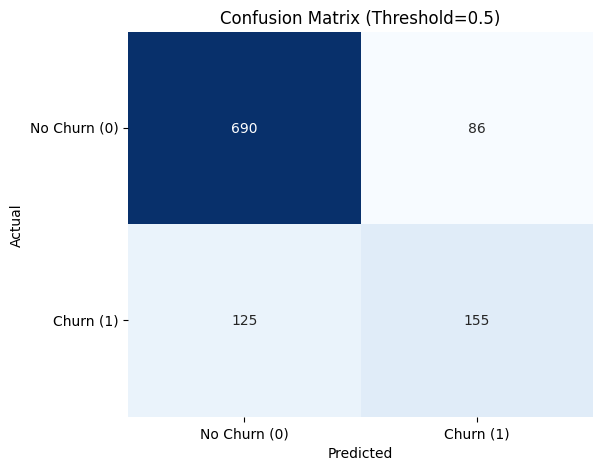

In [36]:
print("Test metrike (threshold=0.5):")
print("Precision:", precision_score(y_val, y_pred_val))
print("Recall:", recall_score(y_val, y_pred_val))
print("F1:", f1_score(y_val, y_pred_val))
print("PR AUC:", average_precision_score(y_val, y_prob_val))
plot_confusion_matrix(y_val, y_pred_val, title='Confusion Matrix (Threshold=0.5)')

### Threshold Optimization

To prioritize recall and reduce false negatives, different classification thresholds are evaluated using the F2-score. The threshold that maximizes the F2-score on the validation set is selected as the optimal threshold.

In [37]:
thresholds = np.linspace(0, 1, 300)
best_f2, best_thr = 0, 0
for thr in thresholds:
    y_pred_thr = (y_prob_val >= thr).astype(int)
    f2 = fbeta_score(y_val, y_pred_thr, beta=2)
    if f2 > best_f2:
        best_f2 = f2
        best_thr = thr

print("Best threshold:", best_thr)
print("Best F2 on val:", best_f2)

Best threshold: 0.15719063545150502
Best F2 on val: 0.7624633431085044


Final metrics (optimal threshold):
Precision: 0.4444444444444444
Recall: 0.9285714285714286
F1: 0.6011560693641619


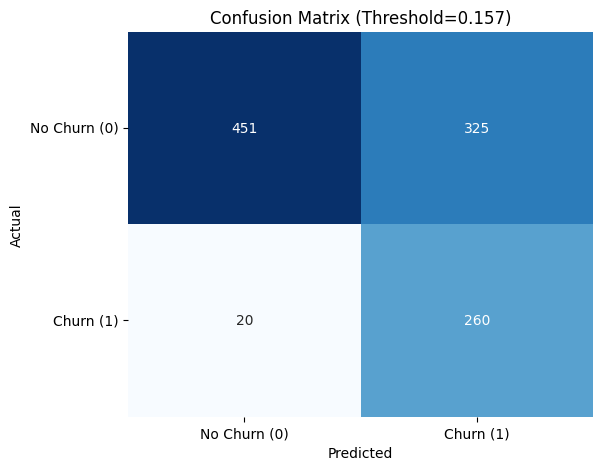

In [38]:
y_pred_final = (y_prob_val >= best_thr).astype(int)
print("Final metrics (optimal threshold):")
print("Precision:", precision_score(y_val, y_pred_final))
print("Recall:", recall_score(y_val, y_pred_final))
print("F1:", f1_score(y_val, y_pred_final))
plot_confusion_matrix(y_val, y_pred_final, title=f'Confusion Matrix (Threshold={best_thr:.3f})')

### Calibration Curve

Calibration curves are used to compare predicted probabilities with observed outcomes. The calibrated and uncalibrated models are compared to assess probability reliability.


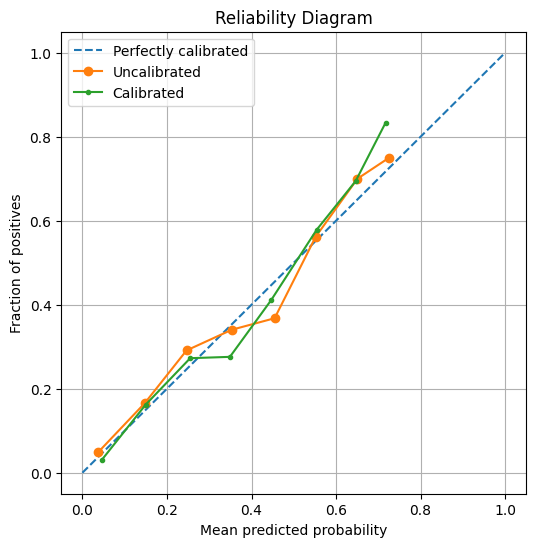

In [39]:
fop_cal, mpv_cal = calibration_curve(y_val, y_prob_val, n_bins=10)
fop_uncal, mpv_uncal = calibration_curve(y_val, y_prob_val_uncal, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot([0,1],[0,1],'--', label='Perfectly calibrated')
plt.plot(mpv_uncal, fop_uncal, marker='o', label='Uncalibrated')
plt.plot(mpv_cal, fop_cal, marker='.', label='Calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Reliability Diagram')
plt.legend()
plt.grid(True)
plt.show()

### Precision, Recall, and F1 Across Thresholds

Precision, recall, and F1-score are evaluated across a range of classification thresholds. The comparison between calibrated and uncalibrated models highlights the impact of calibration on decision boundaries.


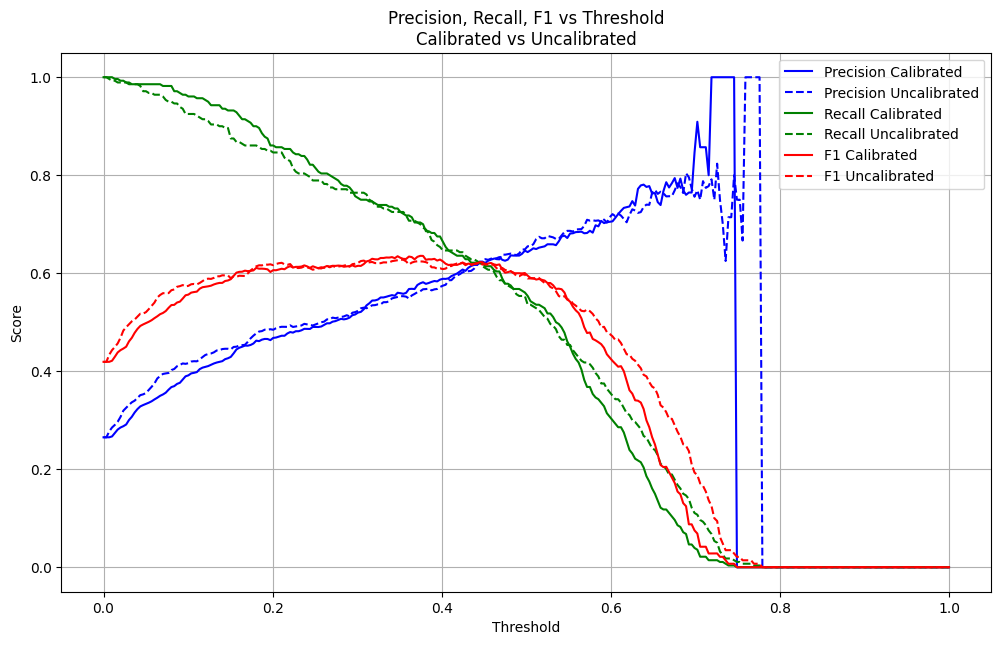

In [40]:
thresholds = np.linspace(0, 1, 300)

precision_cal, recall_cal, f1_cal = [], [], []
precision_uncal, recall_uncal, f1_uncal = [], [], []

for thr in thresholds:
    # Kalibrisani
    y_pred_cal = (y_prob_val >= thr).astype(int)
    precision_cal.append(precision_score(y_val, y_pred_cal))
    recall_cal.append(recall_score(y_val, y_pred_cal))
    f1_cal.append(f1_score(y_val, y_pred_cal))
    
    # Nekalibrisani
    y_pred_uncal = (y_prob_val_uncal >= thr).astype(int)
    precision_uncal.append(precision_score(y_val, y_pred_uncal))
    recall_uncal.append(recall_score(y_val, y_pred_uncal))
    f1_uncal.append(f1_score(y_val, y_pred_uncal))

plt.figure(figsize=(12, 7))

# Precision
plt.plot(thresholds, precision_cal, label='Precision Calibrated', color='blue', linestyle='-')
plt.plot(thresholds, precision_uncal, label='Precision Uncalibrated', color='blue', linestyle='--')

# Recall
plt.plot(thresholds, recall_cal, label='Recall Calibrated', color='green', linestyle='-')
plt.plot(thresholds, recall_uncal, label='Recall Uncalibrated', color='green', linestyle='--')

# F1
plt.plot(thresholds, f1_cal, label='F1 Calibrated', color='red', linestyle='-')
plt.plot(thresholds, f1_uncal, label='F1 Uncalibrated', color='red', linestyle='--')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Threshold\nCalibrated vs Uncalibrated')
plt.legend(loc='best')
plt.grid(True)
plt.show()


## Final Model Training and Evaluation

- In this section, the training and validation datasets are combined to train the final SVC model using the optimal hyperparameters. The model is then calibrated to improve the reliability of predicted probabilities.

- The calibrated model is evaluated on the unseen test set using the optimal classification threshold selected during validation. Performance is assessed using average precision, precision, recall, F2-score, and a confusion matrix to evaluate the final churn prediction results.


In [41]:
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

In [42]:
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("svc", SVC(
        kernel="rbf",
        C=c_value,
        gamma=gamma_value,
        probability=True
    ))
])

In [43]:
final_pipeline.fit(X_train_full, y_train_full)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('contract', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [44]:
calibrated_model = CalibratedClassifierCV(
    estimator=final_pipeline,
    method="sigmoid",
    cv=5
)

calibrated_model.fit(X_train_full, y_train_full)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...ility=True))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the colum

In [45]:
y_test_proba = calibrated_model.predict_proba(X_test)[:, 1]

In [46]:
y_test_pred = (y_test_proba >= best_thr).astype(int)

In [47]:
print("AP:", average_precision_score(y_test, y_test_proba))
print("Recall:", recall_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("F2:", fbeta_score(y_test, y_test_pred, beta=2))

AP: 0.6374178450339084
Recall: 0.9217081850533808
Precision: 0.473491773308958
F2: 0.7749850388988629


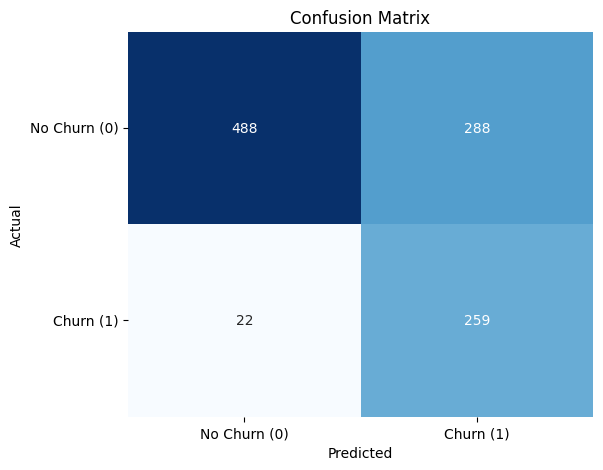

In [48]:
plot_confusion_matrix(y_test, y_test_pred, title='Confusion Matrix')

### Final Model Performance on Test Set

The final calibrated SVC model achieves an average precision of 0.629 on the test set. The recall is relatively high at 0.819, meaning the model successfully identifies most churn customers. Precision is lower (0.537), which indicates that some predicted churn cases are actually non-churn. 

The F2-score of 0.741 shows that the model prioritizes recall over precision, which is important in churn prediction to minimize missed churn customers. 

The confusion matrix confirms this:
- True negatives (No churn correctly predicted): 488
- False positives (No churn predicted as churn): 288
- False negatives (Churn missed): 22
- True positives (Churn correctly predicted): 259

Overall, the model is well-calibrated to identify churn customers, even if it generates some false positives, which is acceptable in a business context where capturing churn is more important than avoiding unnecessary contacts.